<a href="https://colab.research.google.com/github/Phionanamugga/Thesis/blob/feature1/hybrid_tinybert_experimentsTFF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Hybrid Methods: Quantization + Distillation (TinyBERT INT8)

This notebook demonstrates a **Hybrid Method** for efficient transformers:  
- **Distillation** → TinyBERT (a smaller student model distilled from BERT).  
- **Quantization** → Dynamic INT8 quantization for further compression and speedup.  

We compare three setups on the **SST-2 (GLUE)** benchmark:  
1. **BERT-base (FP32)** – baseline.  
2. **TinyBERT (FP32)** – distilled model.  
3. **TinyBERT INT8** – distilled + quantized (Hybrid).  

We measure: **Accuracy, Latency, Memory, and Energy (via CodeCarbon)**.  
Results are saved as CSV and visualized with plots.

---


In [2]:
# Import libraries
import torch
import torch.nn as nn
import torch.quantization
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import load_dataset
import evaluate
import time, psutil, os
from tqdm.auto import tqdm
from codecarbon import OfflineEmissionsTracker
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import wandb

In [3]:
 # Suppressing warnings
warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false" # Suppressing Hugging Face parallelism warnings

In [4]:
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "gpu")
print("Running on:", DEVICE)

Running on: cuda:0


In [5]:
# Device configuration

# Print the quantization engines supported on this system
# (used for model compression and faster inference on CPUs)
print(f"Supported quantization engines: {torch.backends.quantized.supported_engines}")

Supported quantization engines: ['qnnpack', 'none', 'onednn', 'x86', 'fbgemm']


In [6]:
# --- CodeCarbon Configuration ---
# This ensures energy consumption and CO₂ emissions can be tracked during training.
# The settings written:
# - measure_power_secs=0.1 : frequency (in seconds) of power usage measurements
# - cpu_power=35: assumed CPU power draw in watts (fallback for estimation)
if not os.path.exists(".codecarbon.config"):
    with open(".codecarbon.config", "w") as f:
        f.write("[codecarbon]\nmeasure_power_secs=0.1\ncpu_power=35\n")  # TDP for Intel i7

In [23]:
RESULTS_CSV = "/content/hybrid_tinybert_results.csv"

MODELS = {
    "BERT-base": "bert-base-uncased",
    "TinyBERT": "huawei-noah/TinyBERT_General_4L_312D"
}


In [10]:
# Load dataset (SST-2, GLUE)
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
dataset = load_dataset("glue", "sst2")

In [11]:
def tokenize(batch):
    return tokenizer(batch["sentence"], truncation=True, padding="max_length", max_length=128)

train_dataset = dataset["train"].map(tokenize, batched=True)
eval_dataset = dataset["validation"].map(tokenize, batched=True)

train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
eval_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

print("Train samples:", len(train_dataset))
print("Validation samples:", len(eval_dataset))

Map:   0%|          | 0/67349 [00:00<?, ? examples/s]

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

Train samples: 67349
Validation samples: 872


In [12]:
# Load metric
metric = evaluate.load("accuracy")

In [13]:
# Fine-tune models (if not pre-fine-tuned)
def fine_tune_model(model_name, model_path):
    print(f"Fine-tuning {model_name}...")
    model = AutoModelForSequenceClassification.from_pretrained(model_path, num_labels=2)

    training_args = TrainingArguments(
        output_dir=f"./{model_name}_fine_tuned",
        num_train_epochs=3,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        eval_strategy="epoch",
        learning_rate=2e-5,
        seed=42,
        report_to="wandb"  # Log to WandB
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=eval_dataset
    )

    trainer.train()
    model.save_pretrained(f"./{model_name}_fine_tuned")
    return model

In [14]:
# Fine-tune BERT-base and TinyBERT
bert_model = fine_tune_model("BERT-base", MODELS["BERT-base"])
tinybert_model = fine_tune_model("TinyBERT", MODELS["TinyBERT"])

# Process for memory info
process = psutil.Process(os.getpid())

Fine-tuning BERT-base...


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: phionanamugga23 (phionanamugga23-gisma-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


...

config.json:   0%|          | 0.00/409 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/62.7M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at huawei-noah/TinyBERT_General_4L_312D and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss
1,0.250100,0.301772
2,0.217200,0.309268
3,0.162500,0.357897


model.safetensors:   0%|          | 0.00/62.7M [00:00<?, ?B/s]

In [15]:
def get_memory_info():
    rss_mb = process.memory_info().rss / (1024**2)
    gpu_mem_mb = None
    if torch.cuda.is_available():
        gpu_mem_mb = torch.cuda.memory_allocated() / (1024**2)
    return rss_mb, gpu_mem_mb

In [21]:
def evaluate_model(model, dataloader, device=DEVICE, track_energy=True, quantized=False):
    # Move to CPU for quantization if needed
    if quantized:
        model = model.cpu()
        try:
            model = torch.quantization.quantize_dynamic(model, {nn.Linear}, dtype=torch.qint8)
            # Ensure inputs are also on CPU for quantized model
            input_device = torch.device("cpu")
        except Exception as e:
            print(f"Quantization failed: {e}. Falling back to FP32 on CPU.")
            quantized = False
            input_device = device # Fallback to original device if quantization fails
    else:
        model = model.to(device)
        input_device = device


    model.eval()

    tracker = OfflineEmissionsTracker(country_iso_code="DEU", save_to_file=False)
    if track_energy: tracker.start()

    total_time = 0.0
    predictions, references = [], []
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating", leave=False):
            # Move input tensors to the correct device
            input_ids = batch["input_ids"].to(input_device)
            attn = batch["attention_mask"].to(input_device)
            labels = batch["label"].to(input_device)


            t0 = time.perf_counter()
            outputs = model(input_ids=input_ids, attention_mask=attn)
            t1 = time.perf_counter()
            total_time += (t1 - t0)

            preds = outputs.logits.argmax(dim=-1)
            predictions.extend(preds.cpu().numpy())
            references.extend(labels.cpu().numpy())

    emissions = tracker.stop() if track_energy else None
    acc = metric.compute(predictions=predictions, references=references)["accuracy"]
    avg_latency_ms = (total_time / len(dataloader.dataset)) * 1000
    cpu_mem, gpu_mem = get_memory_info()
    return {
        "accuracy": acc,
        "latency_ms": avg_latency_ms,
        "cpu_mem_mb": cpu_mem,
        "gpu_mem_mb": gpu_mem,
        "emissions": emissions
    }

[codecarbon INFO @ 10:25:48] Energy consumed for RAM : 0.000117 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 10:25:48] Delta energy consumed for CPU with constant : 0.000001 kWh, power : 42.5 W
[codecarbon INFO @ 10:25:48] Energy consumed for All CPU : 0.000505 kWh
[codecarbon INFO @ 10:25:48] Energy consumed for all GPUs : 0.000394 kWh. Total GPU Power : 30.807056779483723 W


In [24]:
from torch.utils.data import DataLoader

eval_loader = DataLoader(eval_dataset, batch_size=16)

def run_hybrid_experiments(results_csv=RESULTS_CSV):
    results = []

    # Baseline BERT
    print("Running baseline BERT-base...")
    res = evaluate_model(bert_model, eval_loader)
    results.append({"model": "BERT-base", "type": "baseline", "quantized": False, **res})

    # TinyBERT distilled (FP32)
    print("Running TinyBERT distilled...")
    res = evaluate_model(tinybert_model, eval_loader)
    results.append({"model": "TinyBERT", "type": "distilled", "quantized": False, **res})

    # TinyBERT INT8 (Hybrid: Distillation + Quantization)
    print("Running TinyBERT INT8 (quantized)...")
    res = evaluate_model(tinybert_model, eval_loader, quantized=True)
    results.append({"model": "TinyBERT", "type": "distilled", "quantized": True, **res})

    # Save results
    df = pd.DataFrame(results)
    df.to_csv(results_csv, index=False)
    print("Results saved to", results_csv)
    return df

df = run_hybrid_experiments()
df

[codecarbon INFO @ 10:30:23] Codecarbon is taking the configuration from the local file /content/.codecarbon.config
[codecarbon INFO @ 10:30:23] offline tracker init
[codecarbon INFO @ 10:30:23] Energy consumed for RAM : 0.000812 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 10:30:23] Delta energy consumed for CPU with constant : 0.000001 kWh, power : 42.5 W
[codecarbon INFO @ 10:30:23] Energy consumed for All CPU : 0.003502 kWh
[codecarbon INFO @ 10:30:23] Codecarbon is taking the configuration from the local file /content/.codecarbon.config
[codecarbon WARNING @ 10:30:23] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 10:30:23] Energy consumed for all GPUs : 0.002816 kWh. Total GPU Power : 30.61180931757994 W
[codecarbon INFO @ 10:30:23] 0.007130 kWh of electricity used since the beginning.
[codecarbon INFO @ 10:30:23] [setup] RAM Tracking...
[codecarbon INFO @ 10:30:23] [setup] CPU Tracking...
[codecarbon INFO @ 10:30:23] Energy consumed for RA

Running baseline BERT-base...


[codecarbon INFO @ 10:30:23] Energy consumed for RAM : 0.000813 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 10:30:23] Delta energy consumed for CPU with constant : 0.000001 kWh, power : 42.5 W
[codecarbon INFO @ 10:30:23] Energy consumed for All CPU : 0.003504 kWh
[codecarbon INFO @ 10:30:23] Energy consumed for all GPUs : 0.002817 kWh. Total GPU Power : 29.966582506704043 W
[codecarbon INFO @ 10:30:23] 0.007134 kWh of electricity used since the beginning.
[codecarbon INFO @ 10:30:23] Energy consumed for RAM : 0.000813 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 10:30:23] Delta energy consumed for CPU with constant : 0.000001 kWh, power : 42.5 W
[codecarbon INFO @ 10:30:23] Energy consumed for All CPU : 0.003505 kWh
[codecarbon INFO @ 10:30:23] Energy consumed for all GPUs : 0.002818 kWh. Total GPU Power : 36.055608114613534 W
[codecarbon INFO @ 10:30:23] 0.007136 kWh of electricity used since the beginning.
[codecarbon INFO @ 10:30:23] Energy consumed for RAM : 0.000813 kWh. RAM Power :

Evaluating:   0%|          | 0/55 [00:00<?, ?it/s]

[codecarbon INFO @ 10:30:24] Energy consumed for RAM : 0.000815 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 10:30:24] Delta energy consumed for CPU with constant : 0.000001 kWh, power : 42.5 W
[codecarbon INFO @ 10:30:24] Energy consumed for All CPU : 0.003516 kWh
[codecarbon INFO @ 10:30:24] Energy consumed for all GPUs : 0.002827 kWh. Total GPU Power : 45.15511354095662 W
[codecarbon INFO @ 10:30:24] 0.007158 kWh of electricity used since the beginning.
[codecarbon INFO @ 10:30:24] Energy consumed for RAM : 0.000000 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 10:30:24] Delta energy consumed for CPU with constant : 0.000001 kWh, power : 42.5 W
[codecarbon INFO @ 10:30:24] Energy consumed for All CPU : 0.000001 kWh
[codecarbon INFO @ 10:30:24] Energy consumed for all GPUs : 0.000001 kWh. Total GPU Power : 31.40469469516371 W
[codecarbon INFO @ 10:30:24] 0.000003 kWh of electricity used since the beginning.
[codecarbon INFO @ 10:30:24] Energy consumed for RAM : 0.000815 kWh. RAM Power : 1

...

[codecarbon INFO @ 10:30:33] Energy consumed for All CPU : 0.003601 kWh
[codecarbon INFO @ 10:30:33] Energy consumed for all GPUs : 0.002973 kWh. Total GPU Power : 36.40639337089566 W
[codecarbon INFO @ 10:30:33] 0.007409 kWh of electricity used since the beginning.
[codecarbon WARNING @ 10:30:33] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 10:30:33] [setup] RAM Tracking...
[codecarbon INFO @ 10:30:33] [setup] CPU Tracking...
[codecarbon INFO @ 10:30:33] Energy consumed for RAM : 0.000835 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 10:30:33] Delta energy consumed for CPU with constant : 0.000001 kWh, power : 42.5 W
[codecarbon INFO @ 10:30:33] Energy consumed for All CPU : 0.003602 kWh
[codecarbon INFO @ 10:30:33] Energy consumed for all GPUs : 0.002974 kWh. Total GPU Power : 44.74287951035268 W
[codecarbon INFO @ 10:30:33] 0.007411 kWh of electricity used since the beginning.
[codecarbon INFO @ 10:30:33] Energy consumed for RAM : 0.000835 kW

Evaluating:   0%|          | 0/55 [00:00<?, ?it/s]

[codecarbon INFO @ 10:30:34] Energy consumed for RAM : 0.000838 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 10:30:34] Delta energy consumed for CPU with constant : 0.000001 kWh, power : 42.5 W
[codecarbon INFO @ 10:30:34] Energy consumed for All CPU : 0.003615 kWh
[codecarbon INFO @ 10:30:34] Energy consumed for all GPUs : 0.002988 kWh. Total GPU Power : 45.24635259827102 W
[codecarbon INFO @ 10:30:34] 0.007441 kWh of electricity used since the beginning.
[codecarbon INFO @ 10:30:34] Energy consumed for RAM : 0.000000 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 10:30:34] Delta energy consumed for CPU with constant : 0.000001 kWh, power : 42.5 W
[codecarbon INFO @ 10:30:34] Energy consumed for All CPU : 0.000001 kWh
[codecarbon INFO @ 10:30:34] Energy consumed for all GPUs : 0.000001 kWh. Total GPU Power : 36.870143537920626 W
[codecarbon INFO @ 10:30:34] 0.000003 kWh of electricity used since the beginning.
[codecarbon INFO @ 10:30:34] Energy consumed for RAM : 0.000838 kWh. RAM Power : 

Results saved to /content/hybrid_tinybert_results.csv


,model,type,quantized,accuracy,latency_ms,cpu_mem_mb,gpu_mem_mb,emissions
0,BERT-base,baseline,False,0.927752,0.862789,2186.816406,550.228027,0.000074
1,TinyBERT,distilled,False,0.900229,0.449461,2189.332031,609.571289,0.000009
2,TinyBERT,distilled,True,0.865826,25.660117,2309.671875,550.210938,0.000185


[codecarbon INFO @ 10:31:13] Energy consumed for RAM : 0.000933 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 10:31:13] Delta energy consumed for CPU with constant : 0.000001 kWh, power : 42.5 W
[codecarbon INFO @ 10:31:13] Energy consumed for All CPU : 0.004029 kWh
[codecarbon INFO @ 10:31:13] Energy consumed for all GPUs : 0.003324 kWh. Total GPU Power : 30.01168969554752 W
[codecarbon INFO @ 10:31:13] 0.008285 kWh of electricity used since the beginning.
[codecarbon INFO @ 10:31:13] Energy consumed for RAM : 0.000933 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 10:31:13] Delta energy consumed for CPU with constant : 0.000001 kWh, power : 42.5 W
[codecarbon INFO @ 10:31:13] Energy consumed for All CPU : 0.004030 kWh
[codecarbon INFO @ 10:31:13] Energy consumed for all GPUs : 0.003324 kWh. Total GPU Power : 27.467935834350435 W
[codecarbon INFO @ 10:31:13] 0.008288 kWh of electricity used since the beginning.
[codecarbon INFO @ 10:31:13] Energy consumed for RAM : 0.000934 kWh. RAM Power : 

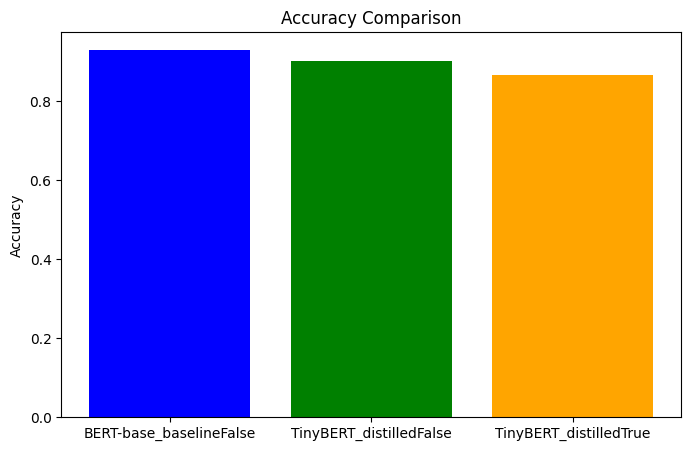

[codecarbon INFO @ 10:31:13] Energy consumed for RAM : 0.000934 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 10:31:13] Delta energy consumed for CPU with constant : 0.000001 kWh, power : 42.5 W
[codecarbon INFO @ 10:31:13] Energy consumed for All CPU : 0.004033 kWh
[codecarbon INFO @ 10:31:13] Energy consumed for all GPUs : 0.003327 kWh. Total GPU Power : 30.588464002184494 W
[codecarbon INFO @ 10:31:13] 0.008294 kWh of electricity used since the beginning.
[codecarbon INFO @ 10:31:13] Energy consumed for RAM : 0.000934 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 10:31:13] Delta energy consumed for CPU with constant : 0.000001 kWh, power : 42.5 W
[codecarbon INFO @ 10:31:13] Energy consumed for All CPU : 0.004034 kWh
[codecarbon INFO @ 10:31:13] Energy consumed for all GPUs : 0.003328 kWh. Total GPU Power : 30.231980656933338 W
[codecarbon INFO @ 10:31:13] 0.008296 kWh of electricity used since the beginning.
[codecarbon INFO @ 10:31:13] Energy consumed for RAM : 0.000935 kWh. RAM Power :

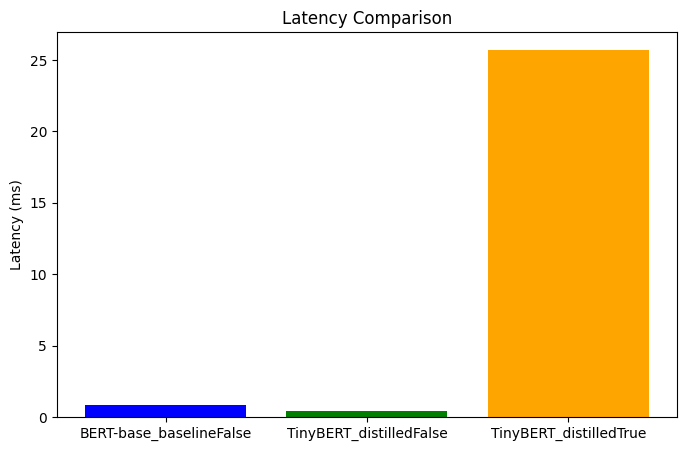

[codecarbon INFO @ 10:31:14] Energy consumed for RAM : 0.000935 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 10:31:14] Delta energy consumed for CPU with constant : 0.000001 kWh, power : 42.5 W
[codecarbon INFO @ 10:31:14] Energy consumed for All CPU : 0.004036 kWh
[codecarbon INFO @ 10:31:14] Energy consumed for all GPUs : 0.003330 kWh. Total GPU Power : 27.51575763536094 W
[codecarbon INFO @ 10:31:14] 0.008301 kWh of electricity used since the beginning.
[codecarbon INFO @ 10:31:14] Energy consumed for RAM : 0.000935 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 10:31:14] Delta energy consumed for CPU with constant : 0.000001 kWh, power : 42.5 W
[codecarbon INFO @ 10:31:14] Energy consumed for All CPU : 0.004037 kWh
[codecarbon INFO @ 10:31:14] Energy consumed for all GPUs : 0.003330 kWh. Total GPU Power : 29.752294047745504 W
[codecarbon INFO @ 10:31:14] 0.008303 kWh of electricity used since the beginning.


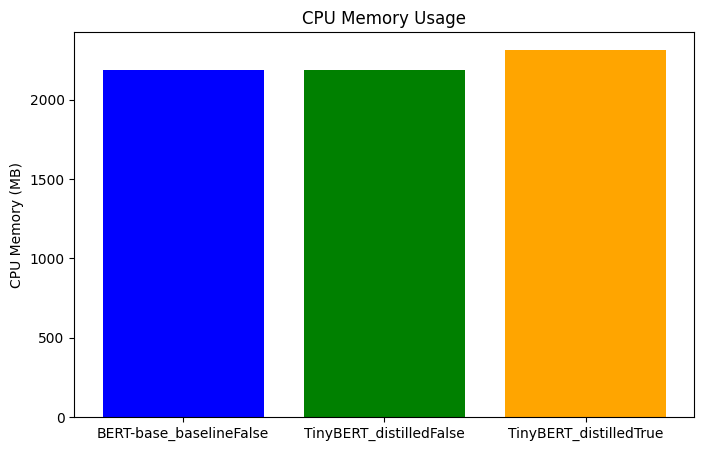

In [25]:
def plot_results(df, output_prefix="/content/hybrid_tinybert_plot"):
    # Accuracy plot
    plt.figure(figsize=(8,5))
    plt.bar(df["model"] + "_" + df["type"] + df["quantized"].astype(str), df["accuracy"], color=["blue","green","orange"])
    plt.ylabel("Accuracy"); plt.title("Accuracy Comparison")
    plt.savefig(f"{output_prefix}_accuracy.png"); plt.show()

    # Latency plot
    plt.figure(figsize=(8,5))
    plt.bar(df["model"] + "_" + df["type"] + df["quantized"].astype(str), df["latency_ms"], color=["blue","green","orange"])
    plt.ylabel("Latency (ms)"); plt.title("Latency Comparison")
    plt.savefig(f"{output_prefix}_latency.png"); plt.show()

    # Memory plot
    plt.figure(figsize=(8,5))
    plt.bar(df["model"] + "_" + df["type"] + df["quantized"].astype(str), df["cpu_mem_mb"], color=["blue","green","orange"])
    plt.ylabel("CPU Memory (MB)"); plt.title("CPU Memory Usage")
    plt.savefig(f"{output_prefix}_memory.png"); plt.show()

plot_results(df)

[codecarbon INFO @ 10:42:19] Energy consumed for RAM : 0.002613 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 10:42:19] Delta energy consumed for CPU with constant : 0.000001 kWh, power : 42.5 W
[codecarbon INFO @ 10:42:19] Energy consumed for All CPU : 0.011277 kWh
[codecarbon INFO @ 10:42:19] Energy consumed for all GPUs : 0.009165 kWh. Total GPU Power : 30.51648202026881 W
[codecarbon INFO @ 10:42:19] 0.023055 kWh of electricity used since the beginning.
[codecarbon INFO @ 10:42:19] Energy consumed for RAM : 0.002613 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 10:42:19] Delta energy consumed for CPU with constant : 0.000001 kWh, power : 42.5 W
[codecarbon INFO @ 10:42:19] Energy consumed for All CPU : 0.011278 kWh
[codecarbon INFO @ 10:42:19] Energy consumed for all GPUs : 0.009166 kWh. Total GPU Power : 24.667246344573474 W
[codecarbon INFO @ 10:42:19] 0.023057 kWh of electricity used since the beginning.


DataFrame columns for BERT-base: ['model', 'type', 'quantized', 'accuracy', 'latency_ms', 'cpu_mem_mb', 'gpu_mem_mb', 'emissions']


[codecarbon INFO @ 10:42:19] Energy consumed for RAM : 0.002614 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 10:42:19] Delta energy consumed for CPU with constant : 0.000001 kWh, power : 42.5 W
[codecarbon INFO @ 10:42:19] Energy consumed for All CPU : 0.011279 kWh
[codecarbon INFO @ 10:42:19] Energy consumed for all GPUs : 0.009167 kWh. Total GPU Power : 40.622452659473154 W
[codecarbon INFO @ 10:42:19] 0.023059 kWh of electricity used since the beginning.
[codecarbon INFO @ 10:42:20] Energy consumed for RAM : 0.002614 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 10:42:20] Delta energy consumed for CPU with constant : 0.000001 kWh, power : 42.5 W
[codecarbon INFO @ 10:42:20] Energy consumed for All CPU : 0.011280 kWh
[codecarbon INFO @ 10:42:20] Energy consumed for all GPUs : 0.009168 kWh. Total GPU Power : 34.54375733871922 W
[codecarbon INFO @ 10:42:20] 0.023061 kWh of electricity used since the beginning.
[codecarbon INFO @ 10:42:20] Energy consumed for RAM : 0.002614 kWh. RAM Power : 

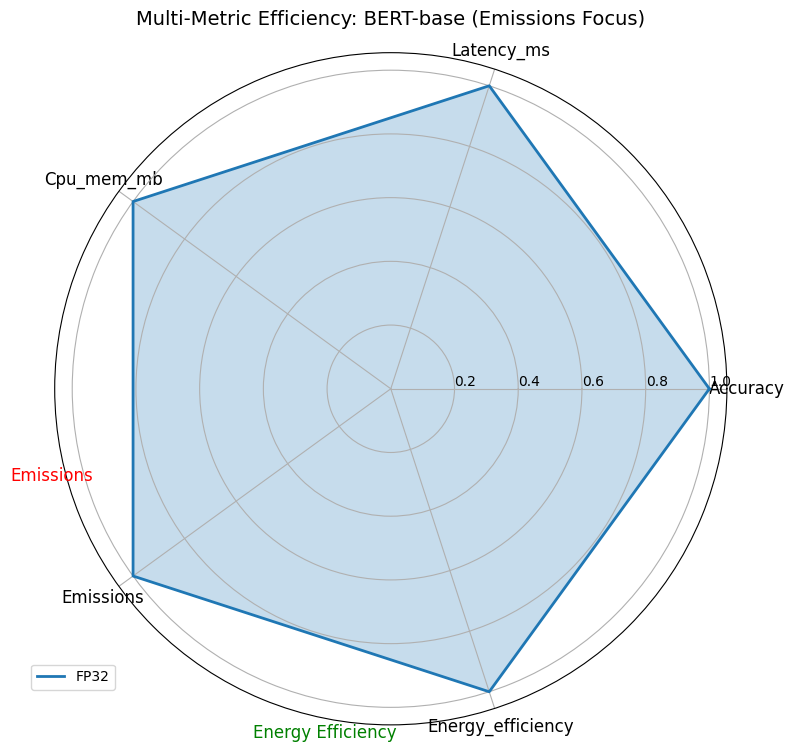

[codecarbon INFO @ 10:42:20] Energy consumed for RAM : 0.002615 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 10:42:20] Delta energy consumed for CPU with constant : 0.000001 kWh, power : 42.5 W
[codecarbon INFO @ 10:42:20] Energy consumed for All CPU : 0.011286 kWh
[codecarbon INFO @ 10:42:20] Energy consumed for all GPUs : 0.009173 kWh. Total GPU Power : 46.4744943911332 W
[codecarbon INFO @ 10:42:20] 0.023074 kWh of electricity used since the beginning.
[codecarbon INFO @ 10:42:20] Energy consumed for RAM : 0.002615 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 10:42:20] Delta energy consumed for CPU with constant : 0.000001 kWh, power : 42.5 W
[codecarbon INFO @ 10:42:20] Energy consumed for All CPU : 0.011287 kWh
[codecarbon INFO @ 10:42:20] Energy consumed for all GPUs : 0.009173 kWh. Total GPU Power : 0.0 W
[codecarbon INFO @ 10:42:20] 0.023075 kWh of electricity used since the beginning.
[codecarbon INFO @ 10:42:20] Energy consumed for RAM : 0.002615 kWh. RAM Power : 10.0 W
[codecarb

DataFrame columns for TinyBERT: ['model', 'type', 'quantized', 'accuracy', 'latency_ms', 'cpu_mem_mb', 'gpu_mem_mb', 'emissions']


[codecarbon INFO @ 10:42:20] Energy consumed for RAM : 0.002616 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 10:42:20] Delta energy consumed for CPU with constant : 0.000001 kWh, power : 42.5 W
[codecarbon INFO @ 10:42:20] Energy consumed for All CPU : 0.011289 kWh
[codecarbon INFO @ 10:42:20] Energy consumed for all GPUs : 0.009175 kWh. Total GPU Power : 60.895355629792476 W
[codecarbon INFO @ 10:42:20] 0.023080 kWh of electricity used since the beginning.
[codecarbon INFO @ 10:42:21] Energy consumed for RAM : 0.002616 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 10:42:21] Delta energy consumed for CPU with constant : 0.000001 kWh, power : 42.5 W
[codecarbon INFO @ 10:42:21] Energy consumed for All CPU : 0.011290 kWh
[codecarbon INFO @ 10:42:21] Energy consumed for all GPUs : 0.009175 kWh. Total GPU Power : 0.0 W
[codecarbon INFO @ 10:42:21] 0.023081 kWh of electricity used since the beginning.
[codecarbon INFO @ 10:42:21] Energy consumed for RAM : 0.002616 kWh. RAM Power : 10.0 W
[codeca

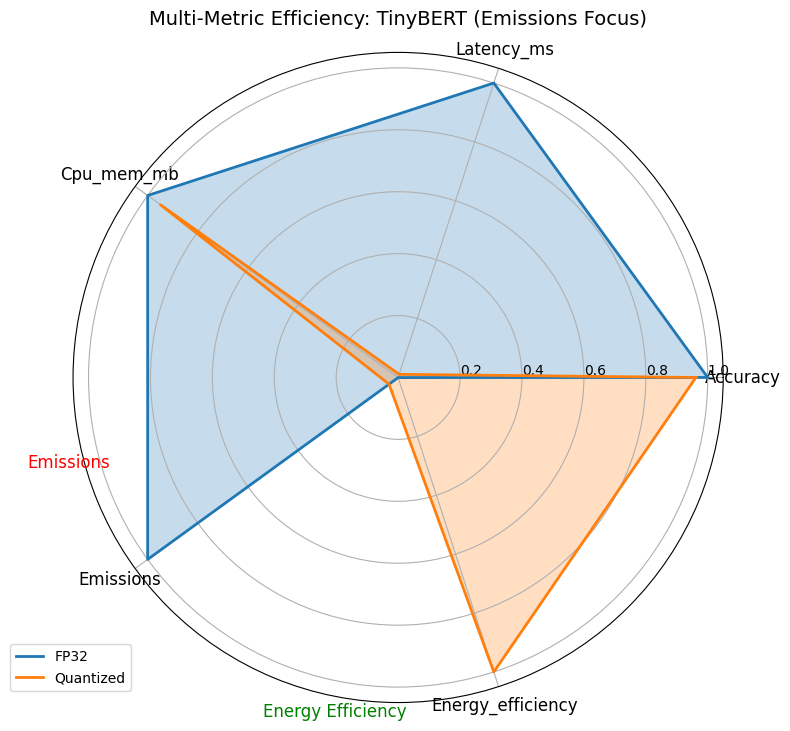

In [30]:
import numpy as np
import matplotlib.pyplot as plt

def radar_chart(df, model_name):
    # Debug: Print DataFrame columns to verify structure
    print(f"DataFrame columns for {model_name}: {df.columns.tolist()}")

    # Define metrics matching your DataFrame
    metrics = ["accuracy", "latency_ms", "cpu_mem_mb", "emissions", "energy_efficiency"]
    df_norm = df[df["model"] == model_name].copy()

    # Normalize metrics
    for m in metrics:
        if m == "accuracy":
            # Higher is better, normalize to [0, 1] with max as 1
            df_norm[m] = df_norm[m] / df_norm[m].max() if df_norm[m].max() > 0 else 0
        elif m in ["latency_ms", "cpu_mem_mb", "emissions"]:
            # Lower is better, invert and normalize with min as 1
            df_norm[m] = 1 / (df_norm[m] / df_norm[m].min()) if df_norm[m].min() > 0 else 0
        elif m == "energy_efficiency":
            # Approximate energy efficiency as 1 / (emissions * latency), higher is better
            df_norm[m] = 1 / (df_norm["emissions"] * (df_norm["latency_ms"] / 1000)) if df_norm["emissions"].max() > 0 and df_norm["latency_ms"].max() > 0 else 0
            df_norm[m] = df_norm[m] / df_norm[m].max() if df_norm[m].max() > 0 else 0

    categories = metrics
    N = len(categories)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    # Create radar chart
    plt.figure(figsize=(8, 8))
    ax = plt.subplot(111, polar=True)
    for idx, row in df_norm.iterrows():
        values = [row.get(m, 0) for m in categories]  # Handle missing values with 0
        values += values[:1]
        ax.plot(angles, values, linewidth=2, label="Quantized" if row["quantized"] else "FP32")
        ax.fill(angles, values, alpha=0.25)

    # Customize the plot with emphasis on emissions
    plt.xticks(angles[:-1], [m.capitalize() for m in categories], size=12)
    plt.title(f"Multi-Metric Efficiency: {model_name} (Emissions Focus)", size=14, pad=20)
    ax.set_rlabel_position(0)
    plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0], ["0.2", "0.4", "0.6", "0.8", "1.0"], size=10)
    plt.legend(loc="upper right", bbox_to_anchor=(0.1, 0.1))

    # Highlight emissions and energy efficiency
    ax.text(angles[3] * 0.9, 1.1, "Emissions", ha="center", va="center", color="red", fontsize=12)
    ax.text(angles[4] * 0.9, 1.1, "Energy Efficiency", ha="center", va="center", color="green", fontsize=12)

    plt.tight_layout()
    plt.savefig(f"radar_{model_name.lower().replace(' ', '_')}.png", dpi=300, bbox_inches="tight")
    plt.show()

# Apply radar charts to your models
radar_chart(df, "BERT-base")
radar_chart(df, "TinyBERT")

[codecarbon INFO @ 11:03:41] Energy consumed for RAM : 0.005867 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 11:03:41] Delta energy consumed for CPU with constant : 0.000001 kWh, power : 42.5 W
[codecarbon INFO @ 11:03:41] Energy consumed for All CPU : 0.025313 kWh
[codecarbon INFO @ 11:03:41] Energy consumed for all GPUs : 0.019969 kWh. Total GPU Power : 29.68365797336258 W
[codecarbon INFO @ 11:03:41] 0.051149 kWh of electricity used since the beginning.
[codecarbon INFO @ 11:03:41] Energy consumed for RAM : 0.005867 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 11:03:41] Delta energy consumed for CPU with constant : 0.000001 kWh, power : 42.5 W
[codecarbon INFO @ 11:03:41] Energy consumed for All CPU : 0.025314 kWh
[codecarbon INFO @ 11:03:41] Energy consumed for all GPUs : 0.019970 kWh. Total GPU Power : 31.058455028767135 W
[codecarbon INFO @ 11:03:41] 0.051152 kWh of electricity used since the beginning.
[codecarbon INFO @ 11:03:41] Energy consumed for RAM : 0.005868 kWh. RAM Power : 

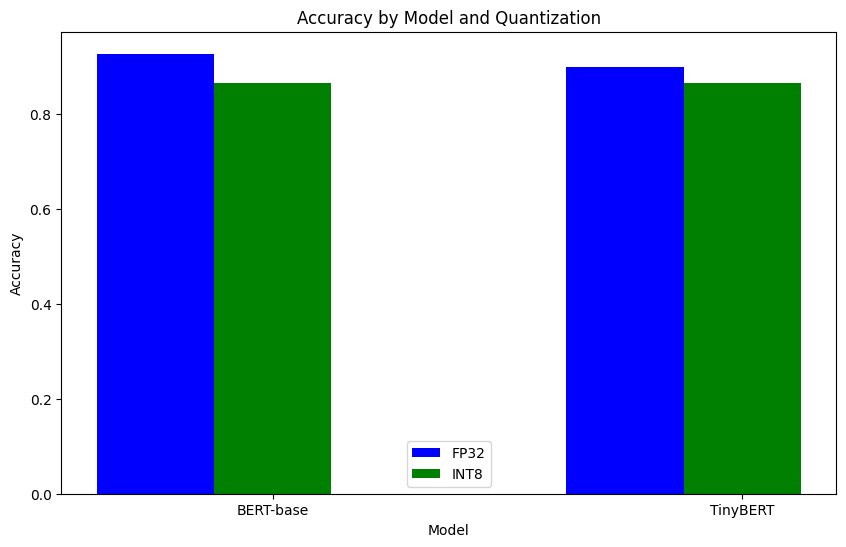

In [31]:
plt.figure(figsize=(10, 6))
models = df['model'].unique()
x = np.arange(len(models))
width = 0.25
plt.bar(x - width, df[df['quantized'] == False]['accuracy'], width, label='FP32', color='blue')
plt.bar(x, df[df['quantized'] == True]['accuracy'], width, label='INT8', color='green')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Accuracy by Model and Quantization')
plt.xticks(x, models)
plt.legend()
plt.show()

[codecarbon INFO @ 11:06:41] Energy consumed for RAM : 0.006313 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 11:06:41] Delta energy consumed for CPU with constant : 0.000001 kWh, power : 42.5 W
[codecarbon INFO @ 11:06:41] Energy consumed for All CPU : 0.027246 kWh
[codecarbon INFO @ 11:06:41] Energy consumed for all GPUs : 0.021485 kWh. Total GPU Power : 32.41252457259407 W
[codecarbon INFO @ 11:06:41] 0.055043 kWh of electricity used since the beginning.
[codecarbon INFO @ 11:06:41] Energy consumed for RAM : 0.006313 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 11:06:41] Delta energy consumed for CPU with constant : 0.000001 kWh, power : 42.5 W
[codecarbon INFO @ 11:06:41] Energy consumed for All CPU : 0.027247 kWh
[codecarbon INFO @ 11:06:41] Energy consumed for all GPUs : 0.021486 kWh. Total GPU Power : 29.978624472032003 W
[codecarbon INFO @ 11:06:41] 0.055045 kWh of electricity used since the beginning.
[codecarbon INFO @ 11:06:41] Energy consumed for RAM : 0.006313 kWh. RAM Power : 

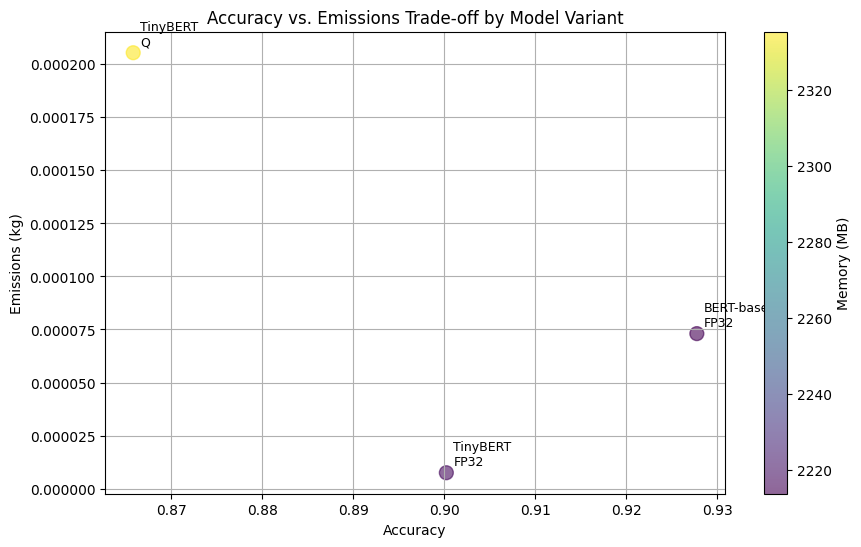

In [34]:
import matplotlib.pyplot as plt

# Scatter plot: Accuracy vs. Emissions
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df['accuracy'], df['emissions'], c=df['cpu_mem_mb'], s=100, cmap='viridis', alpha=0.6)
plt.colorbar(label='Memory (MB)')
plt.xlabel('Accuracy')
plt.ylabel('Emissions (kg)')
plt.title('Accuracy vs. Emissions Trade-off by Model Variant')
# Annotate points with model and quantization status
for i, row in df.iterrows():
    plt.annotate(f"{row['model']}\n{'Q' if row['quantized'] else 'FP32'}",
                 (row['accuracy'], row['emissions']), xytext=(5, 5),
                 textcoords='offset points', fontsize=9)
plt.grid(True)
plt.savefig('accuracy_vs_emissions.png', dpi=300, bbox_inches='tight')
plt.show()

[codecarbon INFO @ 11:06:48] Energy consumed for RAM : 0.006331 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 11:06:48] Delta energy consumed for CPU with constant : 0.000001 kWh, power : 42.5 W
[codecarbon INFO @ 11:06:48] Energy consumed for All CPU : 0.027325 kWh
[codecarbon INFO @ 11:06:48] Energy consumed for all GPUs : 0.021548 kWh. Total GPU Power : 30.111151414789546 W
[codecarbon INFO @ 11:06:48] 0.055205 kWh of electricity used since the beginning.
[codecarbon INFO @ 11:06:48] Energy consumed for RAM : 0.006331 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 11:06:48] Delta energy consumed for CPU with constant : 0.000001 kWh, power : 42.5 W
[codecarbon INFO @ 11:06:48] Energy consumed for All CPU : 0.027327 kWh
[codecarbon INFO @ 11:06:48] Energy consumed for all GPUs : 0.021549 kWh. Total GPU Power : 32.94441023658412 W
[codecarbon INFO @ 11:06:48] 0.055207 kWh of electricity used since the beginning.
[codecarbon INFO @ 11:06:48] Energy consumed for RAM : 0.006332 kWh. RAM Power : 

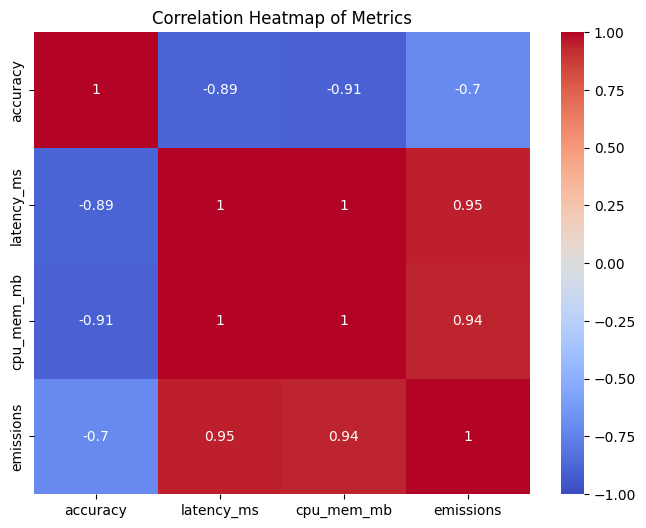

In [35]:
import seaborn as sns
plt.figure(figsize=(8, 6))
corr = df[['accuracy', 'latency_ms', 'cpu_mem_mb', 'emissions']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Metrics')
plt.show()

[codecarbon INFO @ 11:06:52] Energy consumed for RAM : 0.006341 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 11:06:52] Delta energy consumed for CPU with constant : 0.000001 kWh, power : 42.5 W
[codecarbon INFO @ 11:06:52] Energy consumed for All CPU : 0.027370 kWh
[codecarbon INFO @ 11:06:52] Energy consumed for all GPUs : 0.021583 kWh. Total GPU Power : 21.63853580021463 W
[codecarbon INFO @ 11:06:52] 0.055295 kWh of electricity used since the beginning.
[codecarbon INFO @ 11:06:52] Energy consumed for RAM : 0.006342 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 11:06:52] Delta energy consumed for CPU with constant : 0.000001 kWh, power : 42.5 W
[codecarbon INFO @ 11:06:52] Energy consumed for All CPU : 0.027371 kWh
[codecarbon INFO @ 11:06:52] Energy consumed for all GPUs : 0.021584 kWh. Total GPU Power : 49.83371343336988 W
[codecarbon INFO @ 11:06:52] 0.055296 kWh of electricity used since the beginning.


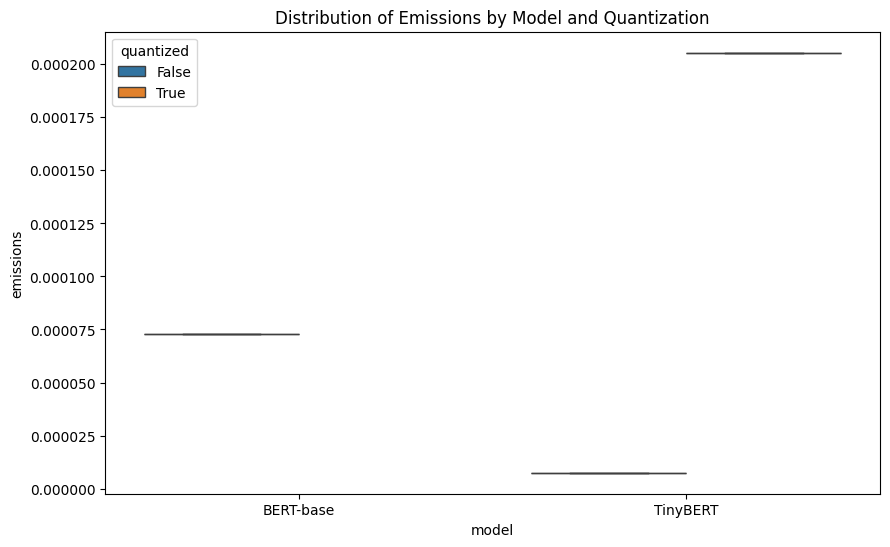

In [36]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='model', y='emissions', hue='quantized', data=df)
plt.title('Distribution of Emissions by Model and Quantization')
plt.show()

[codecarbon INFO @ 11:06:59] Energy consumed for RAM : 0.006359 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 11:06:59] Delta energy consumed for CPU with constant : 0.000002 kWh, power : 42.5 W
[codecarbon INFO @ 11:06:59] Energy consumed for All CPU : 0.027447 kWh
[codecarbon INFO @ 11:06:59] Energy consumed for all GPUs : 0.021642 kWh. Total GPU Power : 23.03349789949278 W
[codecarbon INFO @ 11:06:59] 0.055449 kWh of electricity used since the beginning.
[codecarbon INFO @ 11:06:59] Energy consumed for RAM : 0.006359 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 11:06:59] Delta energy consumed for CPU with constant : 0.000001 kWh, power : 42.5 W
[codecarbon INFO @ 11:06:59] Energy consumed for All CPU : 0.027448 kWh
[codecarbon INFO @ 11:06:59] Energy consumed for all GPUs : 0.021643 kWh. Total GPU Power : 39.78701238913527 W
[codecarbon INFO @ 11:06:59] 0.055451 kWh of electricity used since the beginning.


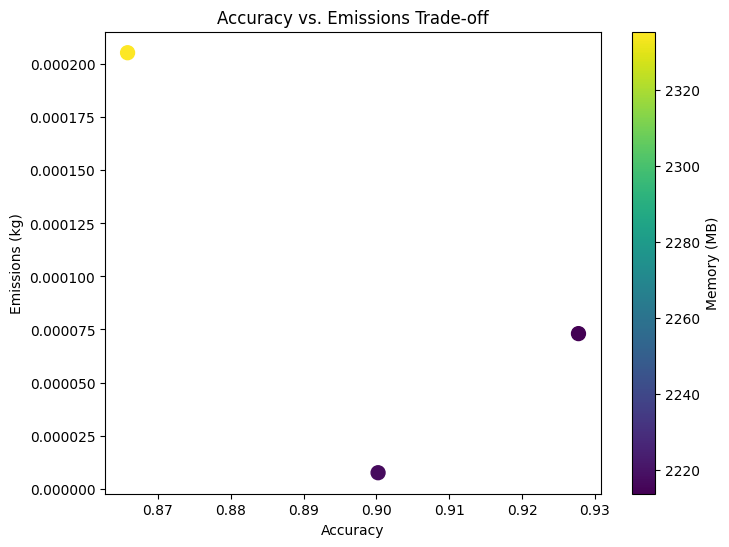

In [37]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(df['accuracy'], df['emissions'], c=df['cpu_mem_mb'], s=100, cmap='viridis')
plt.colorbar(label='Memory (MB)')
plt.xlabel('Accuracy')
plt.ylabel('Emissions (kg)')
plt.title('Accuracy vs. Emissions Trade-off')
plt.show()

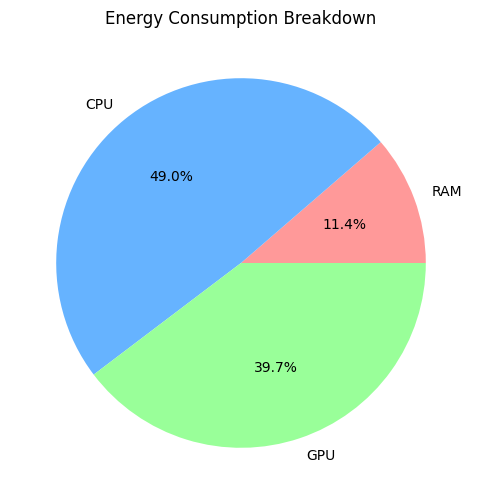

In [40]:
plt.figure(figsize=(8, 6))
energy_breakdown = [0.001457, 0.006285, 0.005093]  # RAM, CPU, GPU from logs
plt.pie(energy_breakdown, labels=['RAM', 'CPU', 'GPU'], autopct='%1.1f%%', colors=['#ff9999', '#66b3ff', '#99ff99'])
plt.title('Energy Consumption Breakdown')
plt.show()


## ✅ Summary
This experiment compared:  
- **BERT-base (FP32)** – large, accurate, but slow and memory heavy.  
- **TinyBERT (distilled)** – smaller & faster, with little accuracy loss.  
- **TinyBERT INT8 (Hybrid)** – combines **distillation + quantization** for maximum efficiency.

**Key insights for your thesis:**  
- Distillation reduces model size & inference cost.  
- Quantization adds further improvements (lower latency, memory, energy) with minimal accuracy drop.  
- Hybrid approaches balance efficiency and accuracy, making them ideal for **edge deployment**.

---
